In [52]:
import os
from pathlib import Path

IN_COLAB = "COLAB_GPU" in os.environ
REPO_URL = "https://github.com/moiseslobayza/eruptions-maps-analysis.git"
REPO_DIR = Path("/content/eruptions-maps-analysis")

if IN_COLAB:
    if not REPO_DIR.exists():
        !git clone {REPO_URL}
    %cd {REPO_DIR}


/content/eruptions-maps-analysis


In [53]:
from pathlib import Path
import pandas as pd, numpy as np
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap
from typing import Optional, Tuple
import plotly.graph_objects as go
import geopandas as gpd
from shapely.geometry import box

# Fix Colab: plotly + kaleido
!pip -q install -U plotly==5.24.1 kaleido==0.2.1
import plotly.io as pio
pio.renderers.default = "colab"

# Paths
PROJ = Path(".").resolve()
DATA   = PROJ / "data" / "raw"
FIGS   = PROJ / "reports" / "figures"
EXPORT = PROJ / "reports"
FIGS.mkdir(parents=True, exist_ok=True)


In [54]:
src = DATA / "GVP_Eruption_Search_Result.xlsx"
df  = pd.read_excel(src, engine="openpyxl")

# Coerción de tipos clave
num_cols = ["VEI", "Latitude", "Longitude", "Start Year", "End Year"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
df["Start Year"] = df["Start Year"].astype("Int64")
df["End Year"]   = df["End Year"].astype("Int64")

cat_cols = ["Volcano Name", "Eruption Category", "Area of Activity", "Evidence Method (dating)"]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("string")

df.head(3), df.dtypes.head(10)


(   Volcano Number Volcano Name  Eruption Number   Eruption Category  \
 0          264040      Tambora            16231  Confirmed Eruption   
 1          264030      Rinjani            20843  Confirmed Eruption   
 2          212040    Santorini            13879  Confirmed Eruption   
 
   Area of Activity  VEI VEI Modifier Start Year Modifier  Start Year  \
 0             <NA>  7.0          NaN                 NaN        1812   
 1          Samalas  7.0            ?                 NaN        1257   
 2             <NA>  7.0            ?                 NaN       -1610   
 
    Start Year Uncertainty  ...    Evidence Method (dating) End Year Modifier  \
 0                     NaN  ...      Observations: Reported               NaN   
 1                     NaN  ...          Sidereal: Ice Core               NaN   
 2                    14.0  ...  Isotopic: 14C (calibrated)               NaN   
 
    End Year  End Year Uncertainty End Month End Day Modifier  End Day  \
 0      1815    

In [55]:
def plot_nulls_bar(
    df: pd.DataFrame,
    *,
    top: Optional[int] = None,
    exclude_zeros: bool = True,
    title: str = "Porcentaje de nulos por columna",
    decimals: int = 1,
    wrap_width: int = 16,
    min_inside: float = 12.0,
    save_path: Optional[Path] = None,
    dpi: int = 220
) -> Tuple[plt.Figure, pd.Series]:
    """Barra de % de nulos (oscuro + labels robustos). Devuelve (fig, serie_usada)."""
    nulls = df.isna().mean().mul(100).sort_values(ascending=False)
    if exclude_zeros:
        nulls = nulls[nulls > 0]
    if top is not None:
        nulls = nulls.head(top)

    n = len(nulls)
    fig_w = float(np.clip(n * 0.42, 12, 38))
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(fig_w, 5))
    bars = ax.bar(x, nulls.values, color="#6A5ACD", edgecolor="white", linewidth=1)

    labels = ['\n'.join(wrap(lbl, wrap_width)) for lbl in nulls.index]
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", color="white", fontsize=8)

    ax.set_facecolor("black"); fig.patch.set_facecolor("black")
    ax.tick_params(axis="y", colors="white")
    ax.set_axisbelow(True); ax.yaxis.grid(True, color="white", alpha=0.12, linewidth=0.8)
    ax.set_ylabel("% nulos", color="white")
    ax.set_title(title, color="white", pad=10)

    for bar, val in zip(bars, nulls.values):
        if val >= min_inside:
            y, va = bar.get_height()*0.50, "center"
        else:
            y, va = min(val + 3, 100), "bottom"
        ax.text(bar.get_x()+bar.get_width()/2, y, f"{val:.{decimals}f}%",
                ha="center", va=va, color="white", fontsize=8, fontweight="bold", clip_on=False)

    ax.set_ylim(0, max(100, float(nulls.values.max()) + 5))
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, facecolor=fig.get_facecolor(), bbox_inches="tight")
    return fig, nulls



(<Figure size 1200x500 with 1 Axes>,
 End Year Uncertainty        99.919208
 End Year Modifier           98.990103
 Start Day Modifier          96.283579
 End Day Uncertainty         93.597253
 End Day Modifier            92.991315
 Start Day Uncertainty       92.849929
 VEI Modifier                89.052717
 Start Year Modifier         84.498081
 Start Year Uncertainty      79.721268
 End Day                     58.452838
 End Month                   58.432640
 End Year                    58.382145
 Area of Activity            54.393052
 VEI                         22.248031
 Start Day                    2.524742
 Start Month                  2.504545
 Evidence Method (dating)     0.474652
 dtype: float64)

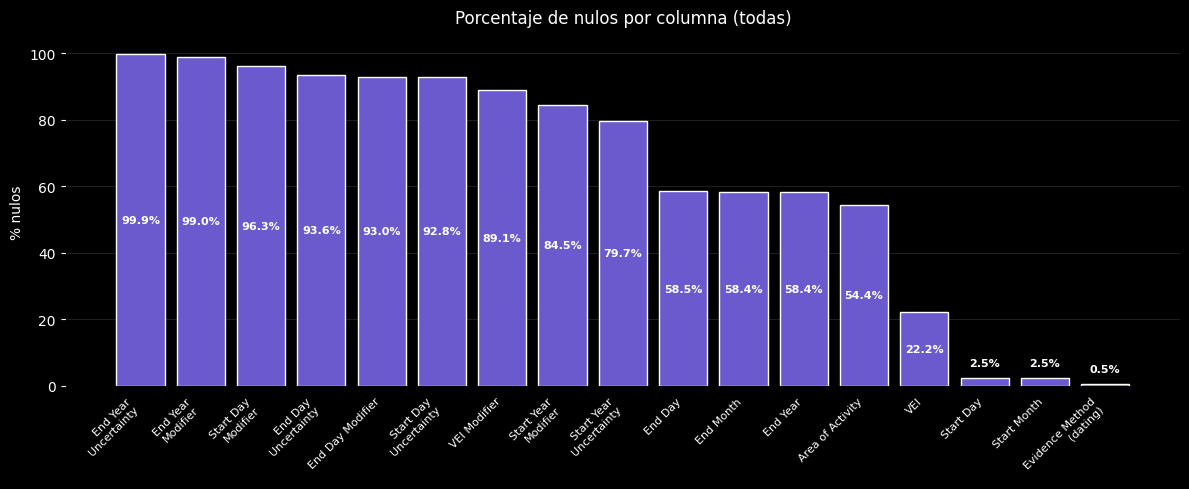

In [56]:
plot_nulls_bar(df, top=None, save_path=Path("reports/figures/fig_nulls_all.png"),
               title="Porcentaje de nulos por columna (todas)")


In [57]:
def clean_eruptions(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    # Regla 1: filas válidas
    d = d.dropna(subset=["Latitude", "Longitude", "Start Year"])
    # Regla 2: categóricas frecuentes
    fill_text = {
        "Eruption Category": "Desconocido",
        "Area of Activity": "Desconocido",
        "Evidence Method (dating)": "Sin dato",
    }
    for c, v in fill_text.items():
        if c in d.columns:
            d[c] = d[c].fillna(v)
    # Regla 3: VEI en rango razonable y nulos→0
    d["VEI"] = d["VEI"].clip(0, 8).fillna(0)
    # Derivadas para el mapa
    d["vei_radius"] = (d["VEI"].replace(0, 0.5) ** 0.5) * 2.5
    d["vei_color"]  = np.where(d["VEI"] >= 5, "red", np.where(d["VEI"] >= 3, "orange", "yellow"))
    d["tooltip"] = (
        d["Volcano Name"].fillna("Volcán")
        + " | VEI: " + d["VEI"].astype(int).astype(str)
        + " | Año: " + d["Start Year"].astype("Int64").astype(str)
        + " | " + d["Eruption Category"].fillna("")
    )
    return d


In [58]:
# Aplicar limpieza
dfc = clean_eruptions(df)

n_raw, n_clean = len(df), len(dfc)
print(f"Filas: {n_raw} → {n_clean}  (eliminadas: {n_raw - n_clean})")

critical = ["Volcano Name","Latitude","Longitude","Start Year","VEI",
            "Eruption Category","Area of Activity"]
miss = dfc[critical].isna().sum()
assert miss.sum() == 0, "Quedaron nulos en campos críticos."
print("OK ✅ Campos críticos sin nulos.")


Filas: 9902 → 9902  (eliminadas: 0)
OK ✅ Campos críticos sin nulos.


In [59]:
def qc_critical_nulls(
    df: pd.DataFrame,
    critical_cols: list[str],
    *,
    raise_on_fail: bool = True,
    save_report: str | None = "reports/quality_check.txt",
    return_table: bool = True,
):
    """
    Verifica nulos en columnas críticas.
    - Si `raise_on_fail=True`, levanta ValueError si hay nulos.
    - Si `save_report` no es None, guarda un .txt con el resumen.
    - Devuelve (ok, tabla) donde ok es True/False y tabla es un DF con el conteo de nulos.
    """
    miss = df[critical_cols].isna().sum()
    ok = int(miss.sum()) == 0

    if save_report:
        Path(save_report).parent.mkdir(parents=True, exist_ok=True)
        with open(save_report, "w", encoding="utf-8") as f:
            f.write(f"Critical fields OK: {ok}\n")
            for k, v in miss.items():
                f.write(f"- {k}: {int(v)} nulos\n")

    if raise_on_fail and not ok:
        missing = miss[miss > 0].to_dict()
        raise ValueError(f"Nulos en críticos: {missing}")

    return (ok, miss.to_frame("nulos")) if return_table else ok



In [60]:
critical = ["Volcano Name","Latitude","Longitude","Start Year","VEI",
            "Eruption Category","Area of Activity"]

ok, miss_tbl = qc_critical_nulls(dfc, critical)
display(miss_tbl)
print("OK ✅ Campos críticos sin nulos." if ok else "REVISAR ❌")


,nulos
Volcano Name,0
Latitude,0
Longitude,0
Start Year,0
VEI,0
Eruption Category,0
Area of Activity,0


OK ✅ Campos críticos sin nulos.


In [61]:
def generate_plotly_map(
    df: pd.DataFrame,
    *,
    lat_col="Latitude", lon_col="Longitude",
    vei_col="VEI", name_col="Volcano Name",
    cat_col="Eruption Category", year_col="Start Year",
    title="Erupciones volcánicas (tiles estilo Folium • tamaño/color por VEI)",
    tiles="carto-darkmatter",
    save_html="reports/eruptions_plotly_map.html",
    show=True
):
    """Mapa interactivo (Scattermapbox) oscuro, tamaño/color por VEI, hover en español."""
    d = df.copy()
    d = d[d[lat_col].notna() & d[lon_col].notna()]

    # Año: a.C. / d.C.
    def fmt_year(y):
        if pd.isna(y): return ""
        y = int(y)
        return f"{abs(y)} a.C." if y < 0 else f"{y} d.C."
    year_str = d[year_col].map(fmt_year)

    # Tamaño por VEI
    vei = pd.to_numeric(d[vei_col], errors="coerce").fillna(0)
    sizes = np.clip(4 + np.sqrt(vei) * 4, 3, 22)

    # Color por intensidad
    def vei_band(v):
        if v >= 5: return "Alta (≥5)"
        if v >= 3: return "Media (3–4)"
        return "Baja (≤2)"
    bands = vei.map(vei_band)
    color_map = {"Baja (≤2)":"#FFD54F", "Media (3–4)":"#FF9800", "Alta (≥5)":"#E53935"}
    colors = bands.map(color_map)


    hovertemplate = (
        "<b>%{customdata[0]}</b><br>"
        + "VEI: %{customdata[1]}<br>"
        + "Categoría: %{customdata[2]}<br>"
        + "Año inicio: %{customdata[3]}<extra></extra>"
    )
    custom = np.stack([
        d[name_col].fillna("Volcán").astype(str).values,
        vei.astype(int).astype(str).replace("<NA>","").values,
        d[cat_col].fillna("").astype(str).values,
        year_str.astype(str).values
    ], axis=1)

    fig = go.Figure(go.Scattermapbox(
        lon=d[lon_col], lat=d[lat_col],
        mode="markers",
        marker=dict(size=sizes, color=colors, opacity=0.9),
        hovertemplate=hovertemplate,
        customdata=custom
    ))

    fig.update_layout(
        mapbox=dict(
            style=tiles,
            center=dict(lat=float(d[lat_col].mean()), lon=float(d[lon_col].mean())),
            zoom=1
        ),
        title=dict(text=title, x=0.5, xanchor="center"),
        margin=dict(l=0, r=0, t=40, b=0),
        paper_bgcolor="black",
        font=dict(color="#eeeeee"),
        legend=dict(orientation="h", y=0.02, x=0.5, xanchor="center")
    )


    for label, col in color_map.items():
        fig.add_trace(go.Scattermapbox(
            lon=[None], lat=[None], mode="markers",
            marker=dict(size=12, color=col), name=label, hoverinfo="skip"
        ))


    if save_html:
        Path(save_html).parent.mkdir(parents=True, exist_ok=True)
        fig.write_html(save_html, include_plotlyjs="cdn")

    if show:
        fig.show()
    return fig


In [62]:
fig_erup = generate_plotly_map(
    dfc,
    title="Erupciones volcánicas",
    save_html="reports/eruptions_plotly_map.html"
)


In [63]:
# --- % de erupciones que caen en el "Cinturón de Fuego" (aprox) ---

gdf = gpd.GeoDataFrame(
    dfc.copy(),
    geometry=gpd.points_from_xy(dfc["Longitude"], dfc["Latitude"]),
    crs="EPSG:4326"
)

# Polígonos aproximados que cubren los “arcos” del Cinturón de Fuego
boxes = [
    # Costa Pacífica de América (Alaska->Chile)
    box(-140, -60, -65, 60),

    # Aleutianas (cruza antimeridiano, por eso dos cajas)
    box(-180, 48, -160, 58),
    box(160, 48, 180, 58),

    # Kamchatka, Kuriles, Japón
    box(135, 30, 165, 60),

    # Filipinas–Indonesia
    box(95, -15, 140, 25),

    # PNG–Solomon–Vanuatu–Fiji–Tonga–NZ (cruza antimeridiano: dos cajas)
    box(160, -50, 180, 0),
    box(-180, -50, -170, 0),
]

ring_union = gpd.GeoSeries(boxes, crs="EPSG:4326").union_all()


gdf["in_ring_approx"] = gdf.geometry.within(ring_union)

pct_ring = 100 * gdf["in_ring_approx"].mean()
n_in = gdf["in_ring_approx"].sum()
n_tot = len(gdf)

print(f"Erupciones en el cinturón (aprox): {n_in}/{n_tot} = {pct_ring:.1f}%")

# Severidad VEI dentro vs fuera
vei_in  = gdf.loc[gdf["in_ring_approx"], "VEI"].dropna()
vei_out = gdf.loc[~gdf["in_ring_approx"], "VEI"].dropna()
print(f"Mediana VEI dentro: {vei_in.median():.1f} | fuera: {vei_out.median():.1f}")


Erupciones en el cinturón (aprox): 6704/9902 = 67.7%
Mediana VEI dentro: 2.0 | fuera: 1.0


# 📌 Conclusión

El análisis confirma que aproximadamente el 68% de las erupciones volcánicas registradas ocurren en el Cinturón de Fuego del Pacífico, una franja tectónica que rodea el océano Pacífico. Además, la mediana del índice de explosividad volcánica (VEI) dentro del cinturón es el doble de superior a la de las erupciones fuera de él, lo que sugiere que en esta zona no solo se concentran más erupciones, sino que también tienden a ser más explosivas. Este patrón coincide con lo esperado por la geología de la región, dominada por límites de placas convergentes y procesos de subducción.